In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import os, sys
from pathlib import Path
from glob import glob
from tqdm.auto import tqdm

sys.path.append(".")

## Processing UniPen dataset

In [2]:
UNIPEN_DIR = Path("./data/unipen/CDROM/train_r01_v07")

In [3]:

def _extract_char(raw: str) -> str | None:
    """
    Parse the character label from the quoted string in a .SEGMENT line.
    Returns a single Python character, or None if unrecognised.
    """
    # Strip surrounding quotes (single or double)
    s = raw.strip("\"'")

    # Unescape UNIPEN backslash sequences
    if s == "\\\\":     # file contains "\\" → backslash
        return "\\"
    if s == '\\"':      # file contains "\"" → double-quote
        return '"'

    # Keep only single-character labels; multi-char labels are special tokens
    # like "SPC", "DEL", etc. which we cannot map to a glyph.
    if len(s) == 1:
        return s

    return None

# read unipen data/*.dat file
def collect_segments(file_path: Path):
    inc_file_path = None
    segments = []
    with open(file_path, encoding="latin-1", errors="replace") as fh:
        for raw in fh:
            line = raw.strip()
            
            # read meta file description
            if line.startswith(".INCLUDE "):
                inc_rel  = line[9:].strip()
                inc_path = UNIPEN_DIR / "include" / inc_rel
                inc_file_path = inc_path

            # read segment description
            if line.startswith(".SEGMENT CHARACTER "):
                # Format: .SEGMENT CHARACTER <idx> <quality> "<char>"
                rest  = line[len(".SEGMENT CHARACTER "):].strip()
                parts = rest.split(None, 2)   # at most 3 tokens
                if len(parts) < 3:
                    continue

                idx_str = parts[0] # "0", "4-5", "101"
                char_raw = parts[2].strip()  # '"b"', '"\\"', '"\""'

                char = _extract_char(char_raw)
                if char is None:
                    continue

                try:
                    if "-" in idx_str:
                        s, e = idx_str.split("-", 1)
                        start, end = int(s), int(e)
                    else:
                        start = end = int(idx_str)
                except ValueError:
                    continue

                if start > end or start < 0:
                    continue

                segments.append((start, end, char))
            

    return (
        inc_file_path,
        segments
    )

# let's read the corresponding strokes list
def collect_strokes(inc_file_path: Path):
    in_stroke = False
    strokes = []
    current = []
    with open(inc_file_path, encoding="latin-1", errors="replace") as fh:
        for raw in fh:
            line = raw.strip()

            if line == ".PEN_DOWN":
                in_stroke = True
                current = []

            elif line == ".PEN_UP":
                if current:
                    strokes.append(current)
                in_stroke = False 
                current = []  # reset current stroke
            
            elif in_stroke and line and not line.startswith("."):
                # has a coordinate
                parts = line.split()
                current.append([float(parts[0]), float(parts[1])])
    return strokes


# let's run a loop and collect all necessary strokes and segments
data = []
for dirname in ['1a', '1b', '1c', '1d', '2']:
    flist = glob(f"data/{dirname}/**/*.dat", root_dir=UNIPEN_DIR, recursive=True)
    for f in tqdm(flist, desc=f"Processing folder {dirname}"):
        inc_file_path, segments = collect_segments(UNIPEN_DIR / f)
        strokes = collect_strokes(inc_file_path)
        for seg in segments:
            seg_start, seg_end, char = seg
            char_strokes = strokes[seg_start:(seg_end+1)]

            # put the strokes in the data
            data.append({
                "char": char,
                "strokes": char_strokes,
                "source": inc_file_path,
                "source_idx_start": seg_start,
                "source_idx_end": seg_end
            })

Processing folder 1a:   0%|          | 0/634 [00:00<?, ?it/s]

Processing folder 1b:   0%|          | 0/1423 [00:00<?, ?it/s]

Processing folder 1c:   0%|          | 0/2145 [00:00<?, ?it/s]

Processing folder 1d:   0%|          | 0/1222 [00:00<?, ?it/s]

Processing folder 2:   0%|          | 0/2735 [00:00<?, ?it/s]

In [4]:
# Some utility function for plotting
def plot_strokes(strokes: list, ax=None, title='', color='black'):
    if ax is None:
        _, ax = plt.subplots(figsize=(3, 3))
    for stroke in strokes:
        if len(stroke) < 2: continue
        xs = [p[0] for p in stroke]
        ys = [p[1] for p in stroke]  # flip y for standard orientation
        ax.plot(xs, ys, color=color, linewidth=2, solid_capstyle='round')
    ax.set_aspect('equal'); ax.axis('off')
    if title: ax.set_title(title, fontsize=10)
    return ax

<Axes: title={'center': '2'}>

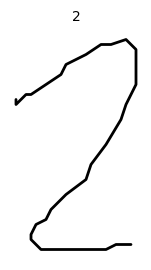

In [9]:
# verify if the obtained strokes look fine
index = 725
plot_strokes(data[index]['strokes'], title = data[index]['char'])

In [9]:
# let's look at the counters of chars
char_counts = {}
for index in range(len(data)):
    char = data[index]['char']
    if char in char_counts:
        char_counts[char] += 1
    else:
        char_counts[char] = 1

char_counts

{'1': 3492,
 '5': 3032,
 '6': 3034,
 '2': 3304,
 '9': 3088,
 '3': 3176,
 '7': 3088,
 '8': 3112,
 '0': 3286,
 '4': 3248,
 'C': 2042,
 'D': 1950,
 'F': 1732,
 'J': 1532,
 'M': 1876,
 'O': 3214,
 'P': 2014,
 'V': 1582,
 'W': 1726,
 'Y': 1772,
 'Z': 1684,
 'A': 2824,
 'E': 3372,
 'N': 2142,
 'Q': 1634,
 'R': 2368,
 'T': 2518,
 'U': 2202,
 'X': 1468,
 'B': 1868,
 'G': 1742,
 'H': 1912,
 'I': 2912,
 'S': 2572,
 'K': 1754,
 'L': 2190,
 'a': 6844,
 'b': 2504,
 'c': 3168,
 'd': 3934,
 'g': 3170,
 'j': 1888,
 'k': 2600,
 'l': 5154,
 's': 5444,
 'u': 3992,
 'v': 1958,
 'w': 2572,
 'z': 2058,
 'e': 9812,
 'f': 2802,
 'i': 6438,
 'm': 3086,
 'n': 6362,
 'o': 6874,
 't': 6010,
 'h': 4164,
 'q': 2250,
 'x': 1742,
 'y': 2646,
 'r': 5602,
 'p': 3354,
 '.': 2532,
 '-': 1728,
 ';': 1182,
 ':': 1326,
 ',': 1376,
 '\\': 1760,
 '$': 906,
 '(': 1582,
 '*': 1080,
 '<': 924,
 '>': 972,
 '?': 904,
 '@': 566,
 '[': 646,
 '`': 288,
 '}': 576,
 '%': 858,
 '&': 566,
 ')': 1870,
 '+': 1152,
 '/': 1324,
 '=': 1036,
 

In [10]:
# store the data as pickle file in processed
import pickle

with open("./data/processed/unipen_parsed.pkl", "wb") as f:
    pickle.dump(data, f)
    f.close()

## Load Data and Perform Model Training

In [11]:
import pickle

with open("./data/processed/unipen_parsed.pkl", "rb") as f:
    data = pickle.load(f)
    f.close()

print(len(data))

223086


In [13]:
data[0].keys()

dict_keys(['char', 'strokes', 'source', 'source_idx_start', 'source_idx_end'])

In [14]:
# extract the list of symbols
SYMBOLS_LIST = list(set([row['char'] for row in data]))
print(f"There are {len(SYMBOLS_LIST)} symbols")

There are 92 symbols


In [33]:
# now create a dataset of the format (Δx, Δy, p_down, p_up, p_end)
def process_strokes(strokes: list[list[tuple[float, float]]]) -> np.ndarray:
    """
    1. Convert absolute stroke lists to delta format.
    2. Returns an (N, 3) array where each row is [Δx, Δy, pen_state].
    The last row always has pen_state == 2 (end-of-sequence)
    3. Translate so first point is at origin; scale so std of Δx,Δy is 1.
    """
    points : list[tuple[float, float, int]] = []
    for stroke in strokes:
        for i, (x, y) in enumerate(stroke):
            pen = 0 if i < len(stroke) - 1 else 1  # last point of stroke -> pen-up
            points.append((x, y, pen))
    if not points:
        return np.zeros((1, 3), dtype=np.float32)
    
    # replace the last pen-up with end of sequence
    points[-1] = (points[-1][0], points[-1][1], 2)

    coords = np.array([(x, y) for x, y, _ in points], dtype=np.float32)
    pens = np.array([p for _, _, p in points], dtype=np.float32)

    deltas = np.diff(coords, axis=0, prepend=coords[:1])  # the first row becomes origin automatically
    deltas_std = deltas.std() + 1e-8
    deltas /= deltas_std

    return np.column_stack([deltas, pens])

process_strokes(data[0]['strokes']).shape

(22, 3)

In [37]:
# prepare the dataloader
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

SYMBOL_TO_IDX = {s: i for i, s in enumerate(SYMBOLS_LIST)}

class StrokeDataset(Dataset):
    """
    Loads the prepared dataset
    Each item returns:
        x_enc   — (max_len, 5)  encoder input  (full sequence, 5-dim one-hot)
        x_dec   — (max_len, 5)  decoder input  (SOS + sequence[:-1])
        char_idx — ()  int64    character label
        length  — ()  int64     un-padded sequence length
    """
    def __init__(self, max_len: int = 200):
        self.data = data 
        self.max_len = max_len

    def __len__(self):
        return len(self.data)
    
    def process_to_5dim(self, seq_3dim: np.ndarray):
        # seq_3dim: (N, 3) numpy array from process_strokes
        xy   = seq_3dim[:, :2]
        pen  = seq_3dim[:, 2].astype(int)
        onehot = np.zeros((len(seq_3dim), 3), dtype=np.float32)
        onehot[np.arange(len(pen)), pen] = 1.0
        return np.concatenate([xy, onehot], axis=1)   # (N, 5)

    def __getitem__(self, idx: int):
        row = self.data[idx]
        seq_3dim = process_strokes(row['strokes'])
        seq = self.process_to_5dim(seq_3dim)
        SOS = np.array([[0, 0, 1, 0, 0]], dtype = np.float32)  # (1, 5)

        x_enc = seq  # (T, 5)
        x_dec = np.concatenate([SOS, seq[:-1]], axis = 0)  # (T, 5)

        # un-padded length
        length = min(len(seq), self.max_len)

        # truncate if longer than max_len
        x_enc = x_enc[:self.max_len]
        x_dec = x_dec[:self.max_len]

        # pad with EOS token if shorter
        pad = self.max_len - len(x_enc)
        if pad > 0:
            eos_rows = np.tile([0, 0, 0, 0, 1], (pad, 1)).astype(np.float32)
            x_enc = np.concatenate([x_enc, eos_rows], axis=0)
            x_dec = np.concatenate([x_dec, eos_rows], axis=0)

        char_idx = SYMBOL_TO_IDX[row['char']]
        return (
            torch.from_numpy(x_enc),                        # (max_len, 5)
            torch.from_numpy(x_dec),                        # (max_len, 5)
            torch.tensor(char_idx, dtype=torch.long),       # ()
            torch.tensor(length,   dtype=torch.long),       # ()
        )
    

# verify the data
stroke_data = StrokeDataset()
for i, (x_enc, x_dec, char_idx, length) in enumerate(stroke_data):
    print(x_enc.shape, x_dec.shape, char_idx, length)
    if i > 2:
        break

torch.Size([200, 5]) torch.Size([200, 5]) tensor(9) tensor(22)
torch.Size([200, 5]) torch.Size([200, 5]) tensor(76) tensor(77)
torch.Size([200, 5]) torch.Size([200, 5]) tensor(27) tensor(41)
torch.Size([200, 5]) torch.Size([200, 5]) tensor(9) tensor(30)


In [38]:
# network constants
CHAR_EMBED_DIM = 64
ENC_HIDDEN     = 256    # per direction; total 2*ENC_HIDDEN fed to VAE head
DEC_HIDDEN     = 512
LATENT_DIM     = 128
MDN_MIXTURES   = 20
INPUT_DIM      = 5      # (Δx, Δy, p_down, p_up, p_end)

In [39]:
# define the networks
class StrokeEncoder(nn.Module):
    """Bidirectional LSTM → VAE latent (μ, log σ²)."""

    def __init__(self, input_dim = INPUT_DIM, hidden = ENC_HIDDEN, latent = LATENT_DIM):
        super().__init__()
        self.lstm   = nn.LSTM(input_dim, hidden, batch_first=True, bidirectional=True)
        self.fc_mu  = nn.Linear(2 * hidden, latent)
        self.fc_lv  = nn.Linear(2 * hidden, latent)   # log-variance

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # x: (B, T, input_dim) -> mu, logvar (each (B, latent_dim))
        _, (h, _) = self.lstm(x)
        h = torch.cat([h[0], h[1]], dim = -1)  # (B, 2 * hidden) - concat both directions
        return self.fc_mu(h), self.fc_lv(h)
    

class StrokeDecoder(nn.Module):
    """
    Single step LSTM cell decoder conditioned on [z || char_embed]
    """
    def __init__(
        self,
        input_dim = INPUT_DIM,
        hidden:      int = DEC_HIDDEN,
        latent:      int = LATENT_DIM,
        mixtures:    int = MDN_MIXTURES,
        num_symbols: int = len(SYMBOLS_LIST),
        embed_dim:   int = CHAR_EMBED_DIM,
    ):
        super().__init__()
        self.hidden   = hidden
        self.mixtures = mixtures
        self.latent   = latent
        self.embed_dim = embed_dim

        self.char_embed = nn.Embedding(num_symbols, embed_dim)
        cond_dim = latent + embed_dim
        self.z_to_h = nn.Linear(cond_dim, hidden)
        self.z_to_c = nn.Linear(cond_dim, hidden)

        self.lstm = nn.LSTMCell(input_dim + cond_dim, hidden)

        # MDN head: M*(π + μx + μy + σx + σy + ρ) + pen logits
        self.fc_out = nn.Linear(hidden, mixtures * 6 + 3)  # this is the MDN head

    def _z_cond(self, z: torch.Tensor, char_idx: torch.Tensor) -> torch.Tensor:
        emb = self.char_embed(char_idx)              # (B, embed_dim)
        return torch.cat([z, emb], dim=-1)           # (B, latent + embed_dim)

    def forward(
        self,
        x:        torch.Tensor,    # (B, T, input_dim)  teacher-forced sequence
        z:        torch.Tensor,    # (B, latent_dim)
        char_idx: torch.Tensor,    # (B,) int
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Returns:
            pi:    (B, T, M)      mixture weights
            mu:    (B, T, M, 2)   means
            sigma: (B, T, M, 2)   std devs  (exp-activated, positive)
            rho:   (B, T, M)      correlations (tanh-activated, ∈ (-1,1))
            q_raw: (B, T, 3)      pen state logits (apply softmax for probs)
        """
        B, T, _ = x.shape
        M = self.mixtures

        z_cond = self._z_cond(z, char_idx)          # (B, cond_dim)
        h = torch.tanh(self.z_to_h(z_cond))         # (B, hidden)
        c = torch.tanh(self.z_to_c(z_cond))

        z_expand = z_cond.unsqueeze(1).expand(-1, T, -1)   # (B, T, cond_dim)
        inp      = torch.cat([x, z_expand], dim=-1)         # (B, T, input_dim+cond_dim)

        outputs = []
        for t in range(T):
            h, c = self.lstm(inp[:, t, :], (h, c))
            outputs.append(h)

        out = self.fc_out(torch.stack(outputs, dim=1))  # (B, T, 6M+3)

        pi_raw  = out[..., :M]
        mu      = out[..., M: 3*M].reshape(B, T, M, 2)
        sig_raw = out[..., 3*M: 5*M].reshape(B, T, M, 2)
        rho_raw = out[..., 5*M: 6*M]
        q_raw   = out[..., 6*M:]

        pi    = F.softmax(pi_raw, dim=-1)
        sigma = torch.exp(sig_raw)
        rho   = torch.tanh(rho_raw)

        return pi, mu, sigma, rho, q_raw

    def step(
        self,
        x_t:      torch.Tensor,    # (1, input_dim)  single step
        z_cond:   torch.Tensor,    # (1, cond_dim)
        h:        torch.Tensor,    # (1, hidden)
        c:        torch.Tensor,    # (1, hidden)
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """Single autoregressive step — used for sampling."""
        inp    = torch.cat([x_t, z_cond], dim=-1)   # (1, input_dim+cond_dim)
        h, c   = self.lstm(inp, (h, c))
        out    = self.fc_out(h)                       # (1, 6M+3)
        M      = self.mixtures

        pi    = F.softmax(out[:, :M],                     dim=-1)
        mu    = out[:, M: 3*M].reshape(1, M, 2)
        sigma = torch.exp(out[:, 3*M: 5*M]).reshape(1, M, 2)
        rho   = torch.tanh(out[:, 5*M: 6*M])
        q_raw = out[:, 6*M:]

        return pi, mu, sigma, rho, q_raw, h, c

In [40]:

# ---------------------------------------------------------------------------
# Loss functions
# ---------------------------------------------------------------------------

def mdn_nll(
    pi:        torch.Tensor,   # (B, T, M)
    mu:        torch.Tensor,   # (B, T, M, 2)
    sigma:     torch.Tensor,   # (B, T, M, 2)  positive
    rho:       torch.Tensor,   # (B, T, M)     ∈ (-1,1)
    target_xy: torch.Tensor,   # (B, T, 2)
) -> torch.Tensor:
    """
    Negative log-likelihood of (Δx, Δy) under the mixture of bivariate Gaussians.

    Bivariate Gaussian log-prob for component k at (x, y):
      log N_k = −Z/(2(1−ρ²)) − log(2π σx σy √(1−ρ²))
      where Z = (zx² − 2ρ·zx·zy + zy²),  zx=(x−μx)/σx,  zy=(y−μy)/σy

    log-mixture = logsumexp_k( log π_k + log N_k )
    loss = −mean( log-mixture )
    """
    xy = target_xy.unsqueeze(2)          # (B, T, 1, 2)

    dx = xy[..., 0] - mu[..., 0]        # (B, T, M)
    dy = xy[..., 1] - mu[..., 1]

    sx = sigma[..., 0].clamp(min=1e-8)
    sy = sigma[..., 1].clamp(min=1e-8)

    zx = dx / sx
    zy = dy / sy
    r2 = (1.0 - rho**2).clamp(min=1e-8)

    Z        = zx**2 - 2.0 * rho * zx * zy + zy**2
    exponent = -Z / (2.0 * r2)

    log_norm = (
        np.log(2 * np.pi)
        + torch.log(sx)
        + torch.log(sy)
        + 0.5 * torch.log(r2)
    )

    log_prob_k  = exponent - log_norm            # (B, T, M)
    log_pi      = torch.log(pi.clamp(min=1e-8))  # (B, T, M)
    log_mixture = torch.logsumexp(log_pi + log_prob_k, dim=-1)  # (B, T)

    return -log_mixture.mean()


def kl_loss(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    """KL( N(μ,σ²) ‖ N(0,I) )  — averaged over batch and latent dims."""
    return -0.5 * torch.mean(1.0 + logvar - mu.pow(2) - logvar.exp())


def pen_loss(q_raw: torch.Tensor, target_pen: torch.Tensor) -> torch.Tensor:
    """Cross-entropy over the 3-class pen state."""
    B, T, _ = q_raw.shape
    return nn.functional.cross_entropy(
        q_raw.reshape(B * T, 3),
        target_pen.reshape(B * T).long(),
    )


In [41]:
class SketchRNN(nn.Module):
    """Character-conditioned Sketch-RNN VAE."""

    def __init__(
        self,
        enc_hidden:  int = ENC_HIDDEN,
        dec_hidden:  int = DEC_HIDDEN,
        latent:      int = LATENT_DIM,
        mixtures:    int = MDN_MIXTURES,
        num_symbols: int = len(SYMBOLS_LIST),
        embed_dim:   int = CHAR_EMBED_DIM,
    ):
        super().__init__()
        self.latent_dim = latent
        self.encoder = StrokeEncoder(INPUT_DIM, enc_hidden, latent)
        self.decoder = StrokeDecoder(INPUT_DIM, dec_hidden, latent, mixtures, num_symbols, embed_dim)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(
        self,
        x_enc:    torch.Tensor,   # (B, T, 5)
        x_dec:    torch.Tensor,   # (B, T, 5)  teacher-forced, starts with SOS
        char_idx: torch.Tensor,   # (B,)  int
    ) -> tuple:
        """
        Returns:
            pi, mu, sigma, rho, q_raw  — MDN outputs from decoder
            z, mu_z, logvar_z          — VAE latent
        """
        mu_z, logvar_z = self.encoder(x_enc)
        z = self.reparameterize(mu_z, logvar_z)
        pi, mu, sigma, rho, q_raw = self.decoder(x_dec, z, char_idx)
        return pi, mu, sigma, rho, q_raw, z, mu_z, logvar_z

    @torch.no_grad()
    def sample(
        self,
        char_idx:    int,
        z:           torch.Tensor | None = None,
        max_len:     int   = 200,
        temperature: float = 0.4,
        device:      str   = "cpu",
    ) -> list[list[list[float]]]:
        """
        Autoregressively generate one glyph for character `char_idx`.

        Args:
            char_idx:    Index into SYMBOL_LABELS (e.g. SYMBOL_TO_IDX['a'])
            z:           (1, latent_dim) style vector; None → sample from prior
            temperature: Controls randomness. Lower = more conservative / cleaner.
            device:      Torch device string.

        Returns:
            List of strokes; each stroke is a list of [x, y] absolute coords.
        """
        if z is None:
            z = torch.randn(1, self.latent_dim, device=device)

        char_t  = torch.tensor([char_idx], dtype=torch.long, device=device)
        z_cond  = self.decoder._z_cond(z, char_t)                # (1, cond_dim)

        h = torch.tanh(self.decoder.z_to_h(z_cond))              # (1, hidden)
        c = torch.tanh(self.decoder.z_to_c(z_cond))

        # SOS token: Δ=(0,0), pen_down=1
        x_t = torch.zeros(1, INPUT_DIM, device=device)
        x_t[0, 2] = 1.0

        strokes: list[list[list[float]]] = []
        current_stroke: list[list[float]] = []
        pos = np.array([0.0, 0.0])

        for _ in range(max_len):
            pi, mu, sigma, rho, q_raw, h, c = self.decoder.step(x_t, z_cond, h, c)

            # --- sample mixture component ---
            pi_t = (pi[0] ** (1.0 / temperature))
            pi_t = pi_t / pi_t.sum()
            k = torch.multinomial(pi_t, 1).item()

            mux  = mu[0, k, 0].item()
            muy  = mu[0, k, 1].item()
            sx   = (sigma[0, k, 0] * temperature ** 0.5).item()
            sy   = (sigma[0, k, 1] * temperature ** 0.5).item()
            rho_k = rho[0, k].item()

            # Sample from bivariate Gaussian via Cholesky decomposition
            eps1, eps2 = np.random.randn(), np.random.randn()
            dx = mux + sx * eps1
            dy = muy + sy * (rho_k * eps1 + np.sqrt(max(1 - rho_k**2, 1e-8)) * eps2)

            pos += np.array([dx, dy])
            current_stroke.append([float(pos[0]), float(pos[1])])

            # --- sample pen state ---
            q_probs = F.softmax(q_raw[0] / temperature, dim=-1)
            pen = torch.multinomial(q_probs, 1).item()

            if pen == 1:      # pen-up after this point → end current stroke
                if len(current_stroke) >= 2:
                    strokes.append(current_stroke)
                current_stroke = []
            elif pen == 2:    # end of sequence
                if len(current_stroke) >= 2:
                    strokes.append(current_stroke)
                break

            # --- build next input ---
            x_t = torch.zeros(1, INPUT_DIM, device=device)
            x_t[0, 0] = float(dx)
            x_t[0, 1] = float(dy)
            x_t[0, 2 + min(pen, 2)] = 1.0

        return strokes


In [42]:
# let's train this network
def compute_loss(
    model: SketchRNN,
    x_enc: torch.Tensor,
    x_dec: torch.Tensor,
    char_idx: torch.Tensor,
    eta: float,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Run forward pass and return (total_loss, reconstruction_loss, kl_loss)."""
    pi, mu, sigma, rho, q_raw, _, mu_z, logvar_z = model(x_enc, x_dec, char_idx)

    # Targets come from x_dec shifted by 1 (x_dec[t] predicts x_enc[t])
    target_xy  = x_enc[..., :2]          # (B, T, 2)
    target_pen = x_enc[..., 2:].argmax(dim=-1)  # (B, T)  one-hot back to int

    loss_r  = mdn_nll(pi, mu, sigma, rho, target_xy) + pen_loss(q_raw, target_pen)
    loss_kl = kl_loss(mu_z, logvar_z)
    loss    = loss_r + eta * loss_kl

    return loss, loss_r, loss_kl

In [43]:
device = torch.device(
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available()
        else "cpu"
    )
print(f"Device: {device}")

Device: mps


In [48]:
# run the model for a input data
model = SketchRNN().to(device)

x_enc, x_dec, char_idx, length = stroke_data[0]
x_enc     = x_enc.unsqueeze(0).to(device)      # (1, T, 5)
x_dec     = x_dec.unsqueeze(0).to(device)      # (1, T, 5)
char_idx  = char_idx.unsqueeze(0).to(device)   # (1,)
model(x_enc, x_dec, char_idx)

(tensor([[[0.0464, 0.0460, 0.0566,  ..., 0.0554, 0.0503, 0.0483],
          [0.0489, 0.0456, 0.0550,  ..., 0.0555, 0.0482, 0.0484],
          [0.0505, 0.0452, 0.0539,  ..., 0.0562, 0.0476, 0.0484],
          ...,
          [0.0537, 0.0439, 0.0528,  ..., 0.0583, 0.0486, 0.0490],
          [0.0537, 0.0439, 0.0528,  ..., 0.0583, 0.0486, 0.0490],
          [0.0537, 0.0439, 0.0528,  ..., 0.0583, 0.0486, 0.0490]]],
        device='mps:0', grad_fn=<SoftmaxBackward0>),
 tensor([[[[-0.0284, -0.0722],
           [ 0.1433, -0.1024],
           [-0.0697,  0.0274],
           ...,
           [ 0.0739,  0.0780],
           [-0.1337, -0.1385],
           [ 0.0499, -0.1258]],
 
          [[-0.0322,  0.0041],
           [ 0.1017, -0.0754],
           [-0.0801, -0.0086],
           ...,
           [ 0.1752,  0.0097],
           [-0.1385, -0.1470],
           [ 0.0878, -0.0528]],
 
          [[-0.0623,  0.0417],
           [ 0.0845, -0.0623],
           [-0.0875, -0.0308],
           ...,
           [ 0.

In [50]:
from torch.utils.data import random_split

# Assume 'dataset' is your PyTorch Dataset object
train_size = int(0.8 * len(stroke_data))
test_size = len(stroke_data) - train_size

train_dataset, test_dataset = random_split(stroke_data, [train_size, test_size])
print(len(train_dataset), len(test_dataset))

178468 44618


In [55]:
BATCH_SIZE = 128

# create dataloaders
def collate_fn(batch):
    x_enc    = torch.stack([b[0] for b in batch])
    x_dec    = torch.stack([b[1] for b in batch])
    char_idx = torch.stack([b[2] for b in batch])
    lengths  = torch.stack([b[3] for b in batch])
    return x_enc, x_dec, char_idx, lengths

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)

In [56]:
NUM_EPOCH = 2

# let's run the training
model     = SketchRNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9999)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")


for epoch in range(1, NUM_EPOCH):
    model.train()
    epoch_loss = epoch_r = epoch_kl = 0.0

    for x_enc, x_dec, char_idx, _ in tqdm(train_loader, total = len(train_loader)):
        x_enc, x_dec = x_enc.to(device), x_dec.to(device)
        char_idx     = char_idx.to(device)

        loss, lr, lkl = compute_loss(model, x_enc, x_dec, char_idx, eta = 1.0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        epoch_r    += lr.item()
        epoch_kl   += lkl.item()

    n = len(train_loader)
    epoch_loss /= n
    epoch_r    /= n
    epoch_kl   /= n

    # run validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_enc, x_dec, char_idx, _ in test_loader:
            x_enc, x_dec = x_enc.to(device), x_dec.to(device)
            char_idx     = char_idx.to(device)
            loss, _, _   = compute_loss(model, x_enc, x_dec, char_idx, eta=1.0)
            val_loss    += loss.item()
    val_loss /= len(test_loader)

    print(
        f"Epoch {epoch:03d}  "
        f"train={epoch_loss:.4f} (r={epoch_r:.4f} kl={epoch_kl:.4f})  "
        f"val={val_loss:.4f}"
    )

Model parameters: 2,392,699


  0%|          | 0/1395 [00:00<?, ?it/s]

KeyboardInterrupt: 